In [2]:
#This notebook determines correlation function estimates for a lattice-based ABM output. 
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pdb
from scipy import integrate
import matplotlib as mpl
from scipy import interpolate
import time

from ABM_package import *
from PDE_FIND3 import * 
from model_selection_IP3 import *
import time, glob
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png', 'pdf')

import os
from correlation_package import *

#increase font size throughout
font = {'size'   : 25}
plt.rc('font', **font)

In [13]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")  # Use GPU
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")   # Fallback to CPU
    print("GPU not available, using CPU")


Using GPU: NVIDIA GeForce RTX 5090 Laptop GPU


In [14]:
rp = 0.05
rd = rp/2
rm = 1.0
f =0.4
den0 = .05

A_out, t_out, plot_list, interp_profiles = BDM_ABM(rp,rd,rm,f,den0, T_end=50.0)

KeyboardInterrupt: 

In [5]:

A_series = plot_list
N = 2
radius = 1.5
corr_dict = correlation_time_series_unordered(A_series, N, radius, global_normalization=True)

NameError: name 'counts_matrix_for_snapshot_unordered' is not defined

In [ ]:
#calculate correlation values at each recorded plot list. compute_F is a function defined in correlation_package.py. It utilizes the function count_occupied_pairs, which counts the occupied pairs of each combination of pairs. 
#F_values = np.array([compute_F(A) for A in plot_list])

In [ ]:
#preprocess F_values in order to visualize across non-dimensional ABM time 
#num_snapshots = len(plot_list)
#T_final = t_out[-1]
#snapshot_times = np.linspace(0, T_final, num_snapshots)

#F_out = interpolate.interp1d(snapshot_times, F_values, kind='linear')(t_out)

#calulate output derivitives
#dF_dt = np.gradient(F_out, t_out)

In [ ]:
plt.figure(figsize=(10,6))

T = len(A_series)
time = np.arange(T)

for pair, series in corr_dict.items():
    i, j = pair
    if i == j:
        plt.plot(time, series, label=f"{i}-{j} (same type)", linewidth=2)
    else:
        plt.plot(time, series, label=f"{i}-{j}")

plt.xlabel("Time step")
plt.ylabel("Correlation coefficient")
plt.title("Correlation Time Series from ABM Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#plot correlation vs time
plt.figure(figsize=(8,5))
plt.plot(t_out, avg_F, label='Correlation F(t)', color='tab:blue')
plt.xlabel('Time')
plt.ylabel('Correlation F')
plt.title('Agent Correlation over Time')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
F_ss = avg_f.mean()  # average 
print("average correlation", F_ss)

In [ ]:
#equation learning
#initialize library of potential RHS terms (polynomials)

Theta = F_out.reshape(-1,1)
description = ['C^1']

deg = 3
for i in np.arange(2,deg+1):
    Theta = np.hstack([Theta, (F_out**i).reshape(-1,1)])
    description.append('C^'+str(i))
    
print("Library terms are ")
print(description)
print("")
#perform linear regression
xi = np.linalg.lstsq(Theta, dF_dt, rcond=None)[0].reshape(-1,1)
print("Learned equation from regression is:")
print(print_pde(xi,description,n=5,ut="dF/dt"))

#Simulate the learned equation and compare to ABM output
RHS = learned_RHS_ODE

u_sim = ODE_sim(xi,RHS,t_out,np.array([F_out[0]]),description=description,deg=deg)

plt.figure(figsize=(9,7))
plt.plot(t_out,u_sim.T,'r--',linewidth=3,label='Learned model')
plt.plot(t_out[::4],F_out[::4],'b.',markersize=20,label='ABM data')
plt.xticks([])
plt.yticks([])
plt.title("Inferred model with regression")
plt.xlabel('Time (T)')
plt.ylabel("Correlation")

#plt.savefig("figures/ABM_tutorial_3.pdf",format="pdf")

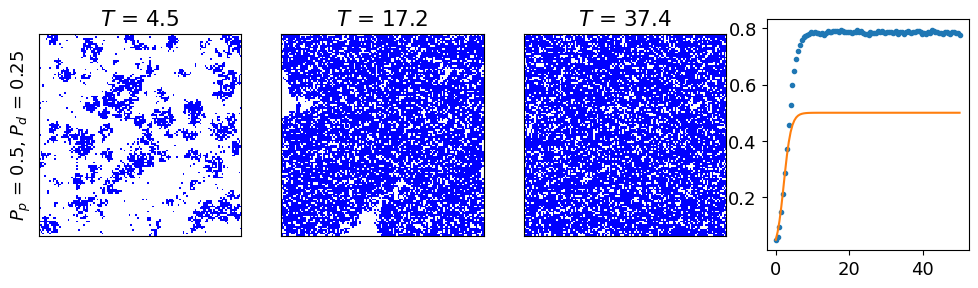

In [11]:
plot_ind = [2,7,15]

cmaplist = [(1.0,1.0,1.0,1.0),(0.0,0.0,1.0,1.0)]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, N = 2)

font = {'size'   : 13}

plt.rc('font', **font)

fig = plt.figure(figsize=(12,3))

ax = fig.add_subplot(1,4,4,adjustable='box')

r = rp-rd
K = r/rp
c0 = 0.05
logist = K*c0*(np.e**(r*t_out))/(K + c0*(np.e**(r*t_out)-1))

ax.plot(t_out*(rp-rd),A_out/plot_list[0].size,'.')
ax.plot(t_out*(rp-rd),logist)

for i in np.arange(3):

    ax = fig.add_subplot(1,4,1+i,adjustable='box')
    ax.matshow(plot_list[plot_ind[i]],cmap=cmap,vmin=0,vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("$T$ = " + str(round(t_out[plot_ind[i]*5-1]*(rp-rd),1)))

    if i == 0:
        ax.set_ylabel("$P_p$ = "+str(rp)+", $P_d$ = "+str(rd))

plt.savefig("nf_plot"+ str(f)+ ".pdf")